# Random Sample imputation for Categorical Data

# Import Libraries

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection  import train_test_split 
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [4]:
df = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [7]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [9]:
df.sample(10)

,FireplaceQu,GarageQual,SalePrice
464,NaN,NaN,124000
1354,TA,TA,235000
1229,NaN,TA,127000
169,TA,TA,228000
1097,NaN,TA,170000
424,Gd,TA,139000
303,NaN,TA,149900
1188,NaN,TA,195000
1146,TA,TA,180000
549,Gd,TA,263000


# Check missing (null) value

In [12]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

# Create X & Y

In [15]:
X = df
y = df['SalePrice']

# Apply Train Test Split

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 2)

In [19]:
X_train

,FireplaceQu,GarageQual,SalePrice
455,TA,TA,175500
863,NaN,TA,132500
504,Fa,TA,147000
1413,Gd,TA,257000
1389,Gd,TA,131000
...,...,...,...
466,Po,TA,167000
299,Gd,TA,158500
493,Fa,TA,155000
527,Gd,TA,446261


# New column create in Both Garage & Fire place

In [42]:
X_train['GarageQual_imputed'] = X_train['GarageQual'] 
X_test['GarageQual_imputed'] = X_test['GarageQual'] 

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu'] 
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [43]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
382,NaN,TA,213500,TA,NaN
1064,Po,TA,154000,TA,Po
665,TA,TA,230500,TA,TA
342,NaN,TA,87500,TA,NaN
55,Gd,TA,180500,TA,Gd


# Replace Garage Value and Fireplace Imputed

In [48]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/856878696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/856878696.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/

# Review Frequency in Garage Original & Imputed

In [50]:
temp = pd.concat([X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()), X_train['GarageQual_imputed'].value_counts() / len(X_train)],axis=1)
temp.columns = ['original', 'imputed']
temp

,original,imputed
TA,0.951043,0.948630
Fa,0.037171,0.040240
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


# Review Frequency in Fireplace Original & Imputed

In [53]:
temp = pd.concat([X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()), X_train['FireplaceQu_imputed'].value_counts() / len(df)],axis=1)
temp.columns = ['original', 'imputed']
temp

,original,imputed
Gd,0.494272,0.393151
TA,0.412439,0.332877
Fa,0.040917,0.030822
Po,0.027823,0.022603
Ex,0.024550,0.020548


# Compare category Fireplace before Imputation

/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/264501118.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  for category in X_train['FireplaceQu'].dropna().unique():sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/264501118.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code t

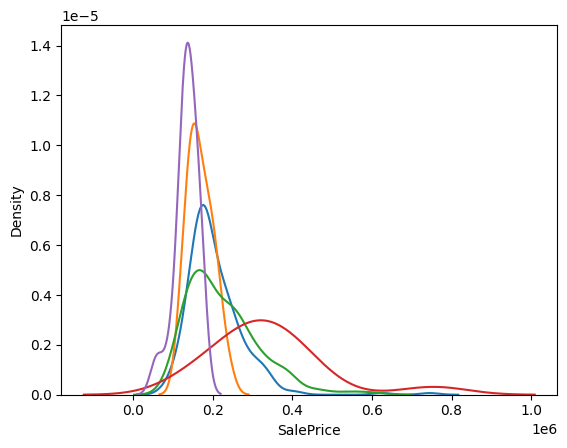

In [56]:
for category in X_train['FireplaceQu'].dropna().unique():sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

# Compare category fireplace after Imputation

/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/4085781156.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  for category in X_train['FireplaceQu_imputed'].dropna().unique():sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
/var/folders/pn/kbp0qf6j4sq1n5vv8_9pvv8m0000gn/T/ipykernel_64968/4085781156.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to up

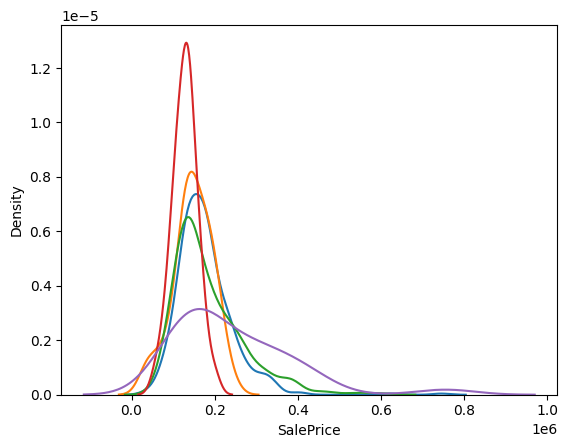

In [57]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()